========== ĐÁNH GIÁ CÁC PATTERN_SIZE ==========
pattern_size = (6, 9) --> 5/7 ảnh
pattern_size = (9, 6) --> 5/7 ảnh

=> pattern_size được chọn: (6, 9)

========== PHÁT HIỆN GÓC CHESSBOARD ==========
[OK] c1.jpg: 54 góc | clahe
[Bỏ qua] c2.jpg
[OK] c3.jpg: 54 góc | equalizeHist
[OK] c4.jpg: 54 góc | equalizeHist
[OK] c5.jpg: 54 góc | gray
[Bỏ qua] c6.jpg
[OK] c7.jpg: 54 góc | equalizeHist

========== KẾT QUẢ ==========
K =
[[938.04793885   0.         634.09599017]
 [  0.         942.71593519 370.53884213]
 [  0.           0.           1.        ]]

dist =
[ 2.17044868e-02  3.76871443e+00  2.32816714e-02  1.31681911e-02
 -2.76734939e+01]


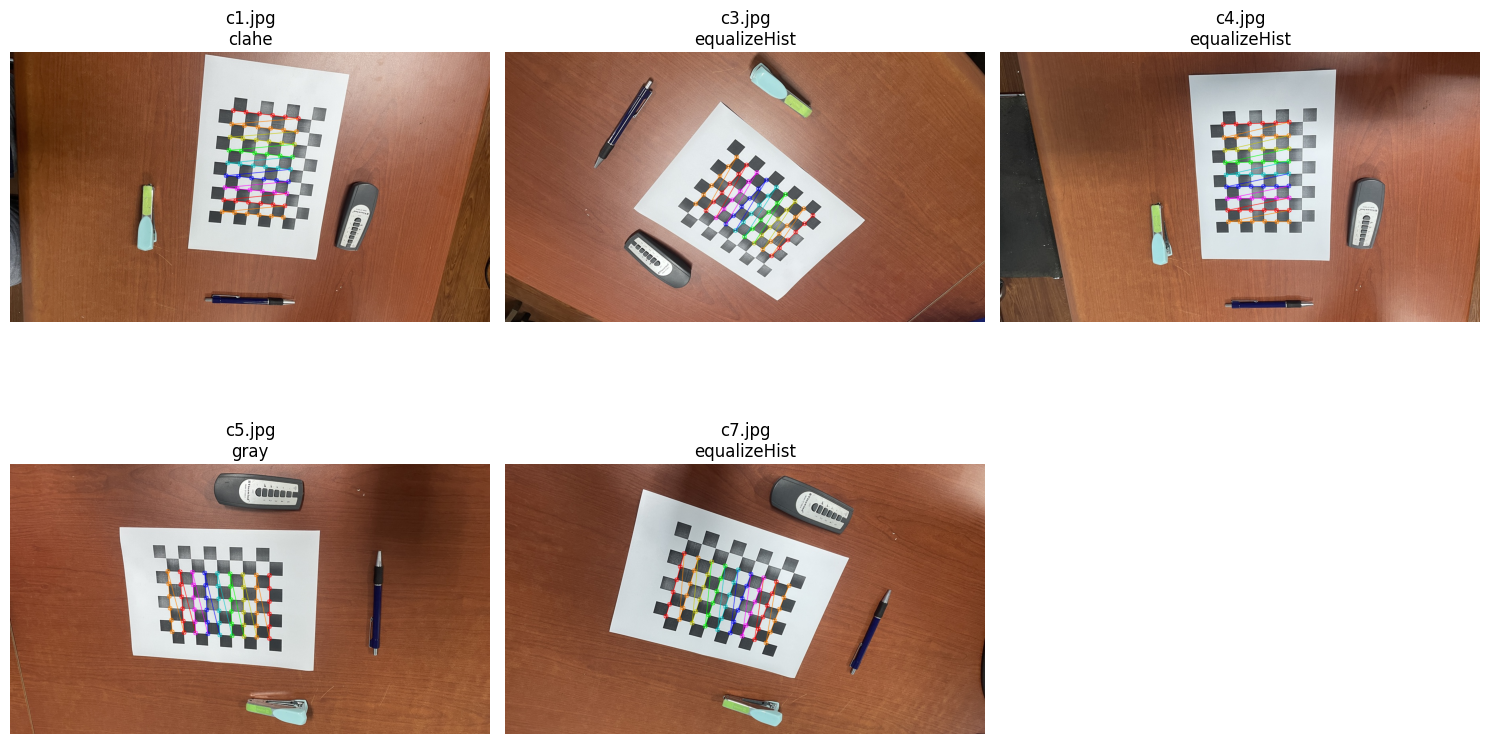

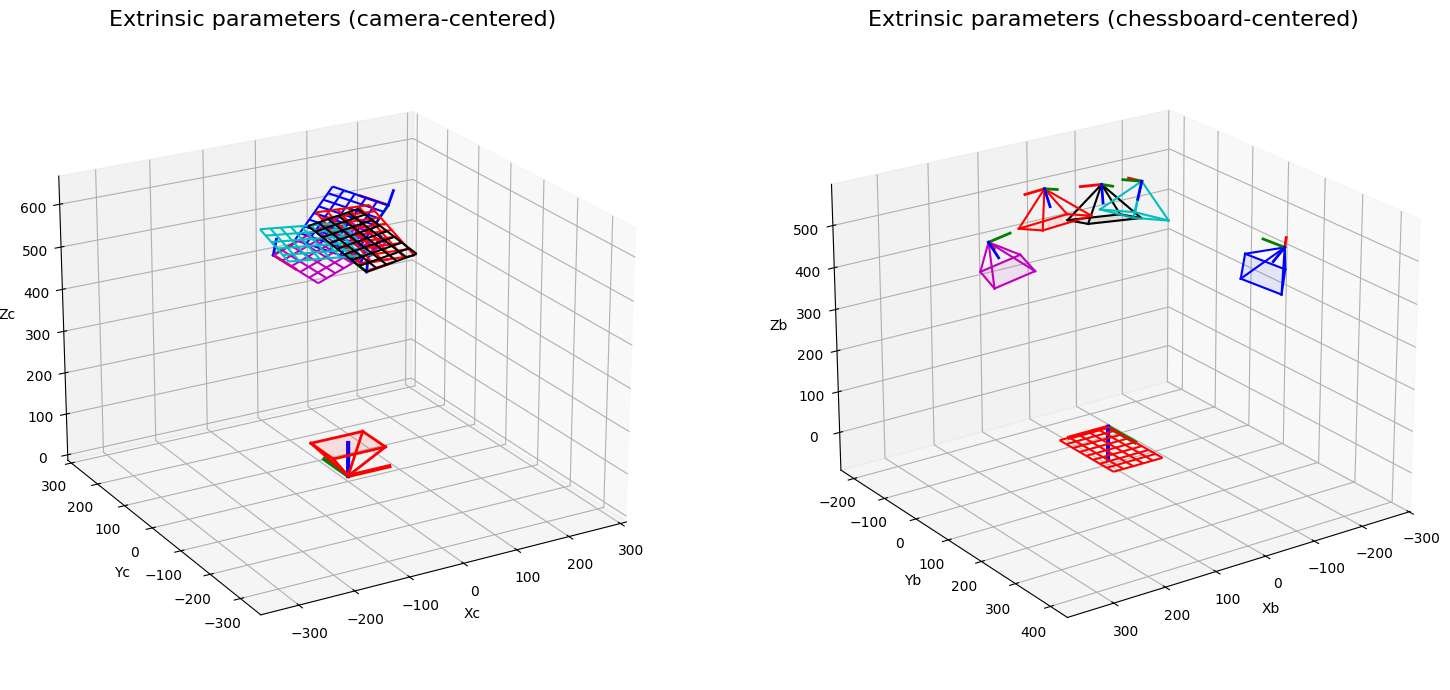

Số ảnh dùng cho calibration: 5
Số điểm 3D trên mỗi ảnh: 54
Số điểm 2D trên mỗi ảnh: 54
Kích thước ảnh dùng cho calibration: (1209, 680)
Sai số reprojection trung bình ret: 0.45686283284244433
K.shape: (3, 3)
dist.shape: (1, 5)

Đã lưu: camera_calibration_result.npz


In [ ]:
# ============================================================
# GIÁO TRÌNH: THỊ GIÁC MÁY: TỪ XỬ LÝ ẢNH ĐẾN HỌC SÂU
# BÀI CODE MINH HỌA: hiệu chỉnh CAMERA VỚI CHESSBOARD SỬ DỤNG OPENCV
# Chương/Mục liên quan: Chương 3 - Mục 3.4.3.3
# ============================================================

# ============================================================
# MÔ TẢ
# ============================================================

# Mục đích:
# - Minh họa quy trình hiệu chỉnh camera với chessboard bằng OpenCV.
# - Phát hiện các góc chessboard trên nhiều ảnh đầu vào.
# - Ước lượng tham số nội K và tham số ngoại rvec, tvec.
# - Trực quan hóa quan hệ hình học giữa camera và chessboard trong không gian 3D.

# Sau khi chạy code, người học cần:
# 1. Quan sát được quá trình phát hiện góc chessboard trên ảnh.
# 2. Hiểu được vai trò của object points và image points trong hiệu chỉnh camera.
# 3. Hiểu được ý nghĩa của ma trận tham số nội và ma trận tham số ngoại.
# 4. Quan sát được vị trí tương đối giữa camera và chessboard trong không gian 3D.

# Input:
# - Dữ liệu đầu vào: 7 ảnh chessboard c1.JPG ... c7.JPG từ GitHub.
# - Kiểu dữ liệu: ảnh màu.
# - URL: https://github.com/lthavnu/cv-book/raw/main/images/calib

# Output:
# - Kết quả phát hiện góc chessboard trên các ảnh hợp lệ.
# - Ma trận tham số nội, ma trận tham số ngoại
# - Trực quan hóa tham số ngoại theo hệ camera-centered và chessboard-centered.
# - File kết quả: camera_calibration_result.npz.

# Lưu ý
# Đoạn code này được xây dựng với sự hỗ trợ của công cụ AI.
# Giảng viên đã đọc, kiểm tra và hiệu chỉnh nhằm bảo đảm tính chính xác,
# tính sư phạm và sự phù hợp với nội dung lý thuyết trong giáo trình.

# Người học không chỉ chạy code để xem kết quả, mà cần hiểu:
# - Code đang minh họa nội dung lý thuyết nào;
# - Các bước xử lý tương ứng với công thức hoặc thuật toán nào;
# - Kết quả đầu ra có hợp lý hay không;
# - Khi thay đổi tham số, kết quả thay đổi như thế nào.

# ============================================================
# 1. CÀI ĐẶT VÀ IMPORT THƯ VIỆN
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

from urllib.request import urlopen
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# ============================================================
# 2. TẢI DỮ LIỆU ĐẦU VÀO VÀ THIẾT LẬP THAM SỐ
# ============================================================

BASE_URL = "https://github.com/lthavnu/cv-book/raw/main/images/calib"

image_urls = [f"{BASE_URL}/c{i}.JPG" for i in range(1, 8)]

# Hai khả năng pattern size cần thử.
# pattern_size là số góc trong của chessboard theo hai chiều.
candidate_pattern_sizes = [
    (6, 9),
    (9, 6),
]

# Kích thước cạnh mỗi ô vuông trên chessboard, đơn vị mm
square_size = 20.0

# Điều kiện dừng cho cornerSubPix
criteria_subpix = (
    cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,
    50,
    1e-4
)

# ============================================================
# 3. ĐỊNH NGHĨA CÁC HÀM HỖ TRỢ
# ============================================================

def read_image_from_url(url):
    # Đọc ảnh từ URL và giải mã thành ảnh màu BGR
    resp = urlopen(url)
    img = np.asarray(bytearray(resp.read()), dtype=np.uint8)
    I_bgr = cv2.imdecode(img, cv2.IMREAD_COLOR)
    return I_bgr


def create_chessboard_object_points(pattern_size, square_size):
    # Tạo tọa độ 3D chuẩn của các góc chessboard trong hệ tọa độ board.
    # Các điểm nằm trên mặt phẳng Z = 0.
    nx, ny = pattern_size

    objp = np.zeros((nx * ny, 3), dtype=np.float32)

    grid_x, grid_y = np.meshgrid(np.arange(nx), np.arange(ny))
    objp[:, 0] = grid_x.flatten() * square_size
    objp[:, 1] = grid_y.flatten() * square_size
    objp[:, 2] = 0.0

    return objp


def build_candidate_gray_images(I_bgr):
    # Tạo nhiều biến thể ảnh xám để tăng độ ổn định khi phát hiện chessboard
    gray = cv2.cvtColor(I_bgr, cv2.COLOR_BGR2GRAY)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    candidate_images = [
        ("gray", gray),
        ("equalizeHist", cv2.equalizeHist(gray)),
        ("clahe", clahe.apply(gray)),
        ("gaussian_blur", cv2.GaussianBlur(gray, (5, 5), 0)),
        ("median_blur", cv2.medianBlur(gray, 5)),
        ("clahe_blur", cv2.GaussianBlur(clahe.apply(gray), (5, 5), 0)),
    ]

    return candidate_images


def detect_chessboard_robust(I_bgr, pattern_size):
    # Phát hiện chessboard bằng nhiều biến thể ảnh và nhiều cấu hình flag
    candidate_images = build_candidate_gray_images(I_bgr)

    candidate_flags = [
        0,
        cv2.CALIB_CB_EXHAUSTIVE,
        cv2.CALIB_CB_ACCURACY,
        cv2.CALIB_CB_EXHAUSTIVE + cv2.CALIB_CB_ACCURACY,
        cv2.CALIB_CB_NORMALIZE_IMAGE,
        cv2.CALIB_CB_NORMALIZE_IMAGE + cv2.CALIB_CB_EXHAUSTIVE,
        cv2.CALIB_CB_NORMALIZE_IMAGE + cv2.CALIB_CB_ACCURACY,
        cv2.CALIB_CB_NORMALIZE_IMAGE + cv2.CALIB_CB_EXHAUSTIVE + cv2.CALIB_CB_ACCURACY,
    ]

    # Ưu tiên detector findChessboardCornersSB
    for img_name, gray_i in candidate_images:
        for flags in candidate_flags:
            found, corners = cv2.findChessboardCornersSB(
                gray_i,
                pattern_size,
                flags
            )

            if found:
                return True, corners.astype(np.float32), gray_i, img_name, flags

    # Fallback sang detector findChessboardCorners thông thường
    for img_name, gray_i in candidate_images:
        flags = cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_NORMALIZE_IMAGE

        found, corners = cv2.findChessboardCorners(
            gray_i,
            pattern_size,
            flags
        )

        if found:
            corners_refined = cv2.cornerSubPix(
                gray_i,
                corners,
                winSize=(11, 11),
                zeroZone=(-1, -1),
                criteria=criteria_subpix
            )

            return True, corners_refined.astype(np.float32), gray_i, img_name, flags

    return False, None, None, None, None


def draw_axes(ax, origin, R=np.eye(3), axis_length=50.0, linewidth=2):
    # Vẽ hệ trục tọa độ 3D tại origin với ma trận định hướng R
    origin = np.asarray(origin).reshape(3)

    x_axis = origin + axis_length * R[:, 0]
    y_axis = origin + axis_length * R[:, 1]
    z_axis = origin + axis_length * R[:, 2]

    ax.plot(
        [origin[0], x_axis[0]],
        [origin[1], x_axis[1]],
        [origin[2], x_axis[2]],
        color="r",
        linewidth=linewidth
    )

    ax.plot(
        [origin[0], y_axis[0]],
        [origin[1], y_axis[1]],
        [origin[2], y_axis[2]],
        color="g",
        linewidth=linewidth
    )

    ax.plot(
        [origin[0], z_axis[0]],
        [origin[1], z_axis[1]],
        [origin[2], z_axis[2]],
        color="b",
        linewidth=linewidth
    )


def create_board_mesh(pattern_size, square_size):
    # Tạo lưới 3D biểu diễn mặt phẳng chessboard
    nx, ny = pattern_size

    board_w = (nx - 1) * square_size
    board_h = (ny - 1) * square_size

    xs = np.linspace(0, board_w, nx)
    ys = np.linspace(0, board_h, ny)

    XX, YY = np.meshgrid(xs, ys)
    ZZ = np.zeros_like(XX)

    return XX, YY, ZZ


def create_camera_frustum(scale=40.0):
    # Tạo mô hình đơn giản của camera gồm tâm camera và mặt phẳng ảnh
    C = np.array([0, 0, 0], dtype=np.float64)

    p1 = np.array([-1, -0.75, 1.5]) * scale
    p2 = np.array([1, -0.75, 1.5]) * scale
    p3 = np.array([1, 0.75, 1.5]) * scale
    p4 = np.array([-1, 0.75, 1.5]) * scale

    return np.stack([C, p1, p2, p3, p4], axis=0)


def transform_points(R, t, points):
    # Biến đổi điểm 3D bằng công thức X' = R X + t
    return (R @ points.T + t.reshape(3, 1)).T


def plot_camera_frustum(ax, points_world, color="r", linewidth=1.5, alpha=0.08):
    # Vẽ mô hình camera trong không gian 3D
    C, p1, p2, p3, p4 = points_world

    edges = [
        (C, p1),
        (C, p2),
        (C, p3),
        (C, p4),
        (p1, p2),
        (p2, p3),
        (p3, p4),
        (p4, p1),
    ]

    for a, b in edges:
        ax.plot(
            [a[0], b[0]],
            [a[1], b[1]],
            [a[2], b[2]],
            color=color,
            linewidth=linewidth
        )

    verts = [[p1, p2, p3, p4]]

    poly = Poly3DCollection(
        verts,
        alpha=alpha,
        facecolor=color,
        edgecolor=color
    )

    ax.add_collection3d(poly)


def set_axes_equal_3d(ax):
    # Cân bằng tỉ lệ các trục để hình 3D không bị méo do thang đo hiển thị
    x_limits = ax.get_xlim3d()
    y_limits = ax.get_ylim3d()
    z_limits = ax.get_zlim3d()

    x_range = abs(x_limits[1] - x_limits[0])
    y_range = abs(y_limits[1] - y_limits[0])
    z_range = abs(z_limits[1] - z_limits[0])

    x_middle = np.mean(x_limits)
    y_middle = np.mean(y_limits)
    z_middle = np.mean(z_limits)

    plot_radius = 0.5 * max(x_range, y_range, z_range)

    ax.set_xlim3d([x_middle - plot_radius, x_middle + plot_radius])
    ax.set_ylim3d([y_middle - plot_radius, y_middle + plot_radius])
    ax.set_zlim3d([z_middle - plot_radius, z_middle + plot_radius])


def evaluate_pattern_size(image_urls, pattern_size):
    # Đếm số ảnh phát hiện được chessboard với một pattern_size cho trước
    success_count = 0

    for url in image_urls:
        I_bgr = read_image_from_url(url)
        found, _, _, _, _ = detect_chessboard_robust(I_bgr, pattern_size)

        if found:
            success_count += 1

    return success_count

# ============================================================
# 4. CHỌN PATTERN SIZE TỐT NHẤT
# ============================================================

print("========== ĐÁNH GIÁ CÁC PATTERN_SIZE ==========")

pattern_scores = {}

for ps in candidate_pattern_sizes:
    count = evaluate_pattern_size(image_urls, ps)
    pattern_scores[ps] = count
    print(f"pattern_size = {ps} --> {count}/{len(image_urls)} ảnh")

pattern_size = max(pattern_scores, key=pattern_scores.get)

print(f"\n=> pattern_size được chọn: {pattern_size}")

# ============================================================
# 5. PHÁT HIỆN GÓC TRÊN TOÀN BỘ ẢNH
# ============================================================

object_points_list = []
image_points_list = []
valid_images_bgr = []
valid_image_names = []
detection_info_list = []

objp = create_chessboard_object_points(pattern_size, square_size)

image_size = None

print("\n========== PHÁT HIỆN GÓC CHESSBOARD ==========")

for i, url in enumerate(image_urls, start=1):
    I_bgr = read_image_from_url(url)
    gray = cv2.cvtColor(I_bgr, cv2.COLOR_BGR2GRAY)
    image_size = (gray.shape[1], gray.shape[0])

    found, corners, _, img_name, flags = detect_chessboard_robust(
        I_bgr,
        pattern_size
    )

    if found:
        object_points_list.append(objp.copy())
        image_points_list.append(corners)
        valid_images_bgr.append(I_bgr)
        valid_image_names.append(f"c{i}.jpg")
        detection_info_list.append((img_name, flags))

        print(f"[OK] c{i}.jpg: {len(corners)} góc | {img_name}")
    else:
        print(f"[Bỏ qua] c{i}.jpg")

if len(object_points_list) < 3:
    raise RuntimeError("Số ảnh phát hiện thành công quá ít.")

# ============================================================
# 6. XỬ LÝ CHÍNH: CAMERA CALIBRATION
# ============================================================

# Thuật toán chính:
# cv2.calibrateCamera sử dụng các cặp điểm 3D trên chessboard
# và điểm 2D phát hiện trên ảnh để ước lượng K, dist, rvecs, tvecs.
ret, K, dist, rvecs, tvecs = cv2.calibrateCamera(
    object_points_list,
    image_points_list,
    image_size,
    None,
    None
)

print("\n========== KẾT QUẢ ==========")

print("K =")
print(K)

print("\ndist =")
print(dist.ravel())

# ============================================================
# 7. HIỂN THỊ ẢNH ĐẦU VÀO KÈM GÓC CHESSBOARD
# ============================================================

n_valid = len(valid_images_bgr)
cols = 3
rows = int(np.ceil(n_valid / cols))

plt.figure(figsize=(15, 4.5 * rows))

for i, (I_bgr, corners, name, info) in enumerate(
    zip(
        valid_images_bgr,
        image_points_list,
        valid_image_names,
        detection_info_list
    ),
    start=1
):
    I_vis = I_bgr.copy()

    cv2.drawChessboardCorners(
        I_vis,
        pattern_size,
        corners,
        True
    )

    I_vis = cv2.cvtColor(I_vis, cv2.COLOR_BGR2RGB)

    plt.subplot(rows, cols, i)
    plt.imshow(I_vis)
    plt.title(f"{name}\n{info[0]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# ============================================================
# 8. HIỂN THỊ KẾT QUẢ: TRỰC QUAN HÓA EXTRINSIC
# ============================================================

XX, YY, ZZ = create_board_mesh(pattern_size, square_size)
camera_model_local = create_camera_frustum(scale=50)

fig = plt.figure(figsize=(16, 7))

# ------------------------------------------------------------
# 8.1. CAMERA-CENTERED
# ------------------------------------------------------------

ax1 = fig.add_subplot(121, projection="3d")
ax1.set_title("Extrinsic parameters (camera-centered)", fontsize=16)

draw_axes(ax1, np.zeros(3), np.eye(3), 80, 3)
plot_camera_frustum(ax1, camera_model_local, "red", 2.0, 0.10)

color_list = ["k", "b", "r", "c", "m", "g", "orange"]

for idx, (rvec, tvec) in enumerate(zip(rvecs, tvecs), start=1):
    R, _ = cv2.Rodrigues(rvec)
    t = tvec.reshape(3, 1)

    # Công thức biến đổi từ hệ board sang hệ camera:
    # X_cam = R X_board + t
    grid_points = np.stack(
        [XX.ravel(), YY.ravel(), ZZ.ravel()],
        axis=1
    )

    grid_points_cam = transform_points(R, t, grid_points)

    XXc = grid_points_cam[:, 0].reshape(XX.shape)
    YYc = grid_points_cam[:, 1].reshape(YY.shape)
    ZZc = grid_points_cam[:, 2].reshape(ZZ.shape)

    color_i = color_list[(idx - 1) % len(color_list)]

    ax1.plot_wireframe(XXc, YYc, ZZc, color=color_i)
    draw_axes(ax1, t.reshape(3), R, 50, 2)

ax1.set_xlabel("Xc")
ax1.set_ylabel("Yc")
ax1.set_zlabel("Zc")
ax1.view_init(elev=22, azim=-120)
set_axes_equal_3d(ax1)

# ------------------------------------------------------------
# 8.2. CHESSBOARD-CENTERED
# ------------------------------------------------------------

ax2 = fig.add_subplot(122, projection="3d")
ax2.set_title("Extrinsic parameters (chessboard-centered)", fontsize=16)

# Đảo dấu trục Z để camera nằm phía trên board khi trực quan hóa
flip_vis = np.diag([1, 1, -1])

board_points = np.stack(
    [XX.ravel(), YY.ravel(), ZZ.ravel()],
    axis=1
)

board_points_vis = (flip_vis @ board_points.T).T

XXv = board_points_vis[:, 0].reshape(XX.shape)
YYv = board_points_vis[:, 1].reshape(YY.shape)
ZZv = board_points_vis[:, 2].reshape(ZZ.shape)

ax2.plot_wireframe(XXv, YYv, ZZv, color="red")
draw_axes(ax2, np.zeros(3), flip_vis, 80, 3)

for idx, (rvec, tvec) in enumerate(zip(rvecs, tvecs), start=1):
    R, _ = cv2.Rodrigues(rvec)
    t = tvec.reshape(3, 1)

    # Công thức tính pose camera trong hệ board:
    # Nếu X_cam = R X_board + t,
    # thì R_cam_in_board = R^T và C_board = -R^T t.
    R_cam_in_board = R.T
    C_board = (-R.T @ t).reshape(3)

    # Đổi sang hệ trực quan hóa
    R_cam_vis = flip_vis @ R_cam_in_board
    C_vis = (flip_vis @ C_board.reshape(3, 1)).reshape(3)

    camera_points_board = transform_points(
        R_cam_vis,
        C_vis.reshape(3, 1),
        camera_model_local
    )

    color_i = color_list[(idx - 1) % len(color_list)]

    plot_camera_frustum(ax2, camera_points_board, color_i, 1.5, 0.08)
    draw_axes(ax2, C_vis, R_cam_vis, 40, 2)

ax2.set_xlabel("Xb")
ax2.set_ylabel("Yb")
ax2.set_zlabel("Zb")
ax2.view_init(elev=22, azim=55)
set_axes_equal_3d(ax2)

plt.tight_layout()
plt.show()

# ============================================================
# 9. KIỂM TRA KẾT QUẢ
# ============================================================

# Kiểm tra số lượng ảnh dùng cho calibration
print("Số ảnh dùng cho calibration:", len(object_points_list))

# Kiểm tra số lượng điểm 3D và điểm 2D trên mỗi ảnh
print("Số điểm 3D trên mỗi ảnh:", object_points_list[0].shape[0])
print("Số điểm 2D trên mỗi ảnh:", image_points_list[0].shape[0])

# Kiểm tra kích thước ảnh
print("Kích thước ảnh dùng cho calibration:", image_size)

# Kiểm tra sai số reprojection trung bình do OpenCV trả về
print("Sai số reprojection trung bình ret:", ret)

# Kiểm tra kích thước ma trận nội tại và vector méo
print("K.shape:", K.shape)
print("dist.shape:", dist.shape)

# ============================================================
# 10. LƯU KẾT QUẢ
# ============================================================

np.savez(
    "camera_calibration_result.npz",
    K=K,
    dist=dist,
    rvecs=np.array(rvecs, dtype=object),
    tvecs=np.array(tvecs, dtype=object),
    pattern_size=np.array(pattern_size),
    square_size=np.array(square_size),
)

print("\nĐã lưu: camera_calibration_result.npz")

# ============================================================
# 11. GỢI Ý THỬ NGHIỆM CHO NGƯỜI HỌC
# ============================================================

# 1. Thay đổi candidate_pattern_sizes để kiểm tra ảnh hưởng của cách chọn số góc chessboard.
# 2. Thay đổi square_size nếu dùng chessboard có kích thước ô vuông khác.
# 3. Thay đổi các biến thể ảnh trong build_candidate_gray_images để quan sát ảnh hưởng đến phát hiện góc.

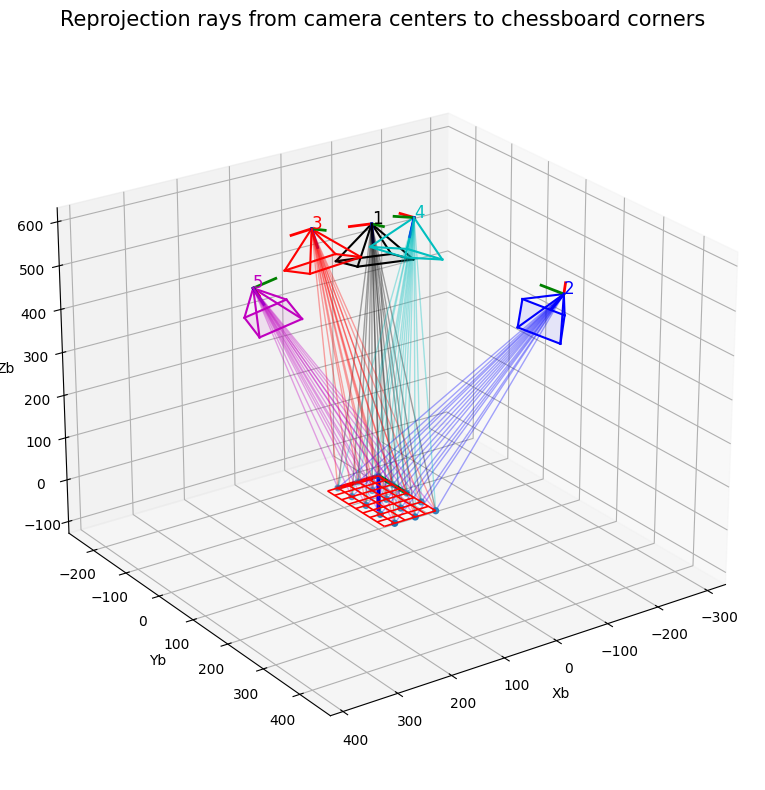

In [ ]:
# ============================================================
# VISUALIZATION REPROJECTION RAYS
# ------------------------------------------------------------
# Chạy sau block calibration trước đó.
#
# Ý tưởng:
#   - Chessboard là gốc tọa độ thế giới
#   - Mỗi camera có tâm C_board = -R^T t trong hệ board
#   - Mỗi góc chessboard là một điểm 3D trên mặt phẳng Z=0
#   - Vẽ các tia nối từ tâm camera đến các góc chessboard
#
# Ghi chú:
#   - Dùng cùng hệ trực quan hóa như block trước:
#       flip_vis = diag([1, 1, -1])
#     để camera nằm phía trên board và nhìn từ trên xuống
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import cv2

# ------------------------------------------------------------
# 1. THAM SỐ HIỂN THỊ
# ------------------------------------------------------------

# Nếu True: vẽ tia tới toàn bộ góc chessboard
# Nếu False: chỉ vẽ các tia mẫu để hình đỡ rối
draw_all_rays = False

# Số bước lấy mẫu theo mỗi chiều khi draw_all_rays = False
sample_step_x = 2
sample_step_y = 2

# Có vẽ mô hình camera hay không
draw_camera_frustums = True

# Có vẽ hệ trục camera hay không
draw_camera_axes = True

# Độ trong suốt của tia
ray_alpha = 0.35

# Độ dày của tia
ray_linewidth = 1.0

# ============================================================
# 2. TẠO CÁC ĐIỂM GÓC CHESSBOARD TRONG HỆ BOARD
# ============================================================

nx, ny = pattern_size

# Tạo lưới góc đúng như object points đã dùng khi calibration
grid_x, grid_y = np.meshgrid(np.arange(nx), np.arange(ny))
corner_points_board = np.stack(
    [
        grid_x * square_size,
        grid_y * square_size,
        np.zeros_like(grid_x, dtype=np.float32)
    ],
    axis=-1
).reshape(-1, 3).astype(np.float32)

# Nếu chỉ muốn vẽ tia mẫu thì lấy thưa bớt
if not draw_all_rays:
    corner_points_grid = corner_points_board.reshape(ny, nx, 3)
    sampled_corner_points_board = corner_points_grid[::sample_step_y, ::sample_step_x, :].reshape(-1, 3)
else:
    sampled_corner_points_board = corner_points_board.copy()

# ============================================================
# 3. HỆ TRỰC QUAN HÓA
# ------------------------------------------------------------
# Đảo trục Z để camera nằm phía trên board
# ============================================================

flip_vis = np.diag([1, 1, -1])

# Board mesh để vẽ
XX, YY, ZZ = create_board_mesh(pattern_size, square_size)
board_points = np.stack([XX.ravel(), YY.ravel(), ZZ.ravel()], axis=1)
board_points_vis = (flip_vis @ board_points.T).T

XXv = board_points_vis[:, 0].reshape(XX.shape)
YYv = board_points_vis[:, 1].reshape(YY.shape)
ZZv = board_points_vis[:, 2].reshape(ZZ.shape)

# Các góc chessboard trong hệ trực quan hóa
sampled_corner_points_vis = (flip_vis @ sampled_corner_points_board.T).T

# Camera model
camera_model_local = create_camera_frustum(scale=50)

# ============================================================
# 4. VẼ REPROJECTION RAYS
# ============================================================

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.set_title("Reprojection rays from camera centers to chessboard corners", fontsize=15)

# Vẽ board
ax.plot_wireframe(XXv, YYv, ZZv, color='red', linewidth=1.2)
draw_axes(ax, np.zeros(3), flip_vis, axis_length=80.0, linewidth=3)

# Vẽ các góc được chọn trên board
ax.scatter(
    sampled_corner_points_vis[:, 0],
    sampled_corner_points_vis[:, 1],
    sampled_corner_points_vis[:, 2],
    s=18
)

for idx, (rvec, tvec) in enumerate(zip(rvecs, tvecs), start=1):
    R, _ = cv2.Rodrigues(rvec)
    t = tvec.reshape(3, 1)

    # Pose camera trong hệ board
    R_cam_in_board = R.T
    C_board = (-R.T @ t).reshape(3)

    # Đổi sang hệ trực quan hóa
    R_cam_vis = flip_vis @ R_cam_in_board
    C_vis = (flip_vis @ C_board.reshape(3, 1)).reshape(3)

    color_i = color_list[(idx - 1) % len(color_list)]

    # Vẽ mô hình camera
    if draw_camera_frustums:
        camera_points_vis = transform_points(
            R_cam_vis,
            C_vis.reshape(3, 1),
            camera_model_local
        )
        plot_camera_frustum(ax, camera_points_vis, color=color_i, linewidth=1.5, alpha=0.08)

    # Vẽ hệ trục camera
    if draw_camera_axes:
        draw_axes(ax, C_vis, R_cam_vis, axis_length=40.0, linewidth=2)

    # Đánh số camera
    ax.text(C_vis[0], C_vis[1], C_vis[2], f"{idx}", fontsize=12, color=color_i)

    # Vẽ các tia từ tâm camera tới các góc chessboard
    for Pw_vis in sampled_corner_points_vis:
        ax.plot(
            [C_vis[0], Pw_vis[0]],
            [C_vis[1], Pw_vis[1]],
            [C_vis[2], Pw_vis[2]],
            color=color_i,
            linewidth=ray_linewidth,
            alpha=ray_alpha
        )

ax.set_xlabel("Xb")
ax.set_ylabel("Yb")
ax.set_zlabel("Zb")
ax.view_init(elev=24, azim=55)
set_axes_equal_3d(ax)

plt.tight_layout()
plt.show()